In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision.models.video import r3d_18, R3D_18_Weights
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

c:\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce RTX 2070 with Max-Q Design


In [2]:
class RouletteVideoDataset(Dataset):
    """
    Dataset for roulette videos.
    Loads video clips and returns tensor of shape (C, T, H, W)
    """
    
    def __init__(self, csv_path, dataset_root, num_frames=16, frame_size=112, transform=None):
        """
        Args:
            csv_path: Path to CSV with columns ['input_path', 'label']
            dataset_root: Root directory of the dataset
            num_frames: Number of frames to sample from each video
            frame_size: Size to resize frames to (frame_size x frame_size)
            transform: Optional transforms to apply
        """
        self.df = pd.read_csv(csv_path)
        self.df = self.df.dropna(subset=['label']).reset_index(drop=True)
        self.dataset_root = Path(dataset_root)
        self.num_frames = num_frames
        self.frame_size = frame_size
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # Get video path and label
        video_rel_path = self.df.iloc[idx]['input_path']
        label = int(self.df.iloc[idx]['label'])
        video_path = self.dataset_root / video_rel_path
        
        frames = self._load_video(video_path)
        
        # Convert to tensor (C, T, H, W)
        if self.transform:
            frames = self.transform(frames)
        
        return frames, label
    
    def _load_video(self, video_path):
        """Load video and sample num_frames"""
        cap = cv2.VideoCapture(str(video_path))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        # Take frames from the beginning only
        if total_frames < self.num_frames:
            # If video has fewer frames, repeat last frame
            indices = list(range(total_frames)) + [total_frames-1] * (self.num_frames - total_frames)
        else:
            indices = list(range(self.num_frames))
            # max_frame = min(int(cap.get(cv2.CAP_PROP_FPS) * 2), total_frames-1)
            # indices = np.linspace(0, max_frame, self.num_frames, dtype=int)
        
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (self.frame_size, self.frame_size))
                frame = frame.astype(np.float32) / 255.0
                frames.append(frame)
        
        cap.release()
        
        # (T, H, W, C)
        frames = np.stack(frames, axis=0)
        
        # Convert to (C, T, H, W) for PyTorch
        frames = torch.from_numpy(frames).permute(3, 0, 1, 2)
        
        return frames

## 3. Model

In [3]:
class RoulettePredictor(nn.Module):
    
    def __init__(self, num_classes=37, freeze_backbone=True):
        """
        Args:
            num_classes: Number of roulette numbers
            freeze_backbone: If True, only train the final layer
        """
        super(RoulettePredictor, self).__init__()
        
        weights = R3D_18_Weights.KINETICS400_V1
        self.model = r3d_18(weights=weights)
        
        if freeze_backbone:
            for param in self.model.parameters():
                param.requires_grad = False
        
        in_features = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        """
            x: (batch, C, T, H, W)
        """
        return self.model(x)
    
    def unfreeze_backbone(self):
        for param in self.model.parameters():
            param.requires_grad = True

model = RoulettePredictor(num_classes=37, freeze_backbone=True)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Total parameters: 33,307,109
Trainable parameters: 140,837


In [4]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    correct_top5 = 0
    total = 0
    
    pbar = tqdm(dataloader, desc='Training')
    for videos, labels in pbar:
        videos, labels = videos.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * videos.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Top-5 accuracy
        _, top5_pred = outputs.topk(5, 1, True, True)
        top5_pred = top5_pred.t()
        correct_top5 += top5_pred.eq(labels.view(1, -1).expand_as(top5_pred)).sum().item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': loss.item(), 
            'acc': 100 * correct / total,
            'top5': 100 * correct_top5 / total
        })
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    epoch_top5_acc = 100 * correct_top5 / total
    return epoch_loss, epoch_acc, epoch_top5_acc

def test(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    correct_top5 = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Testing')
        for videos, labels in pbar:
            videos, labels = videos.to(device), labels.to(device)
            
            outputs = model(videos)
            loss = criterion(outputs, labels)
            
            # Get probabilities
            probs = torch.softmax(outputs, dim=1)
            
            # Statistics
            running_loss += loss.item() * videos.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Top-5 accuracy
            _, top5_pred = outputs.topk(5, 1, True, True)
            top5_pred = top5_pred.t()
            correct_top5 += top5_pred.eq(labels.view(1, -1).expand_as(top5_pred)).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            # Update progress bar
            pbar.set_postfix({
                'loss': loss.item(), 
                'acc': 100 * correct / total,
                'top5': 100 * correct_top5 / total
            })
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    epoch_top5_acc = 100 * correct_top5 / total
    return epoch_loss, epoch_acc, epoch_top5_acc, all_preds, all_labels, all_probs

## 5. Dataset

In [5]:
CONFIG = {
    'dataset_root': 'RouletteVision-Dataset',
    'csv_path': 'dataset_labels_combined.csv',
    'num_frames': 16,
    'frame_size': 112,
    'batch_size': 8,
    'num_workers': 0,
    'train_split': 0.85,
    'learning_rate': 1e-3,
    'num_epochs': 5,
    'save_path': 'roulette_model.pth'
}

dataset = RouletteVideoDataset(
    csv_path=CONFIG['csv_path'],
    dataset_root=CONFIG['dataset_root'],
    num_frames=CONFIG['num_frames'],
    frame_size=CONFIG['frame_size']
)

# Split into train/val
train_size = int(CONFIG['train_split'] * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create sampler for training to handle class imbalance
all_labels = [int(dataset.df.iloc[i]['label']) for i in range(len(dataset))]
train_labels = [all_labels[idx] for idx in train_dataset.indices]

# Count class occurrences in training set
class_counts = np.bincount(train_labels, minlength=37)
class_weights = 1.0 / (class_counts + 1e-6)
sample_weights = [class_weights[label] for label in train_labels]

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    sampler=train_sampler,
    num_workers=CONFIG['num_workers'], 
    pin_memory=True, 
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=CONFIG['batch_size'], 
    shuffle=False, 
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

print(f"Dataset loaded: {len(dataset)} videos")
print(f"   Training: {train_size} videos")
print(f"   Test: {test_size} videos (held out)")

print("Configuration set. Uncomment code above when labels are ready.")

Dataset loaded: 1703 videos
   Training: 1447 videos
   Test: 256 videos (held out)
Configuration set. Uncomment code above when labels are ready.


In [6]:
# Test data loading
print("Testing train_loader...")
print(f"Total batches in train_loader: {len(train_loader)}")
print(f"Batch size: {CONFIG['batch_size']}")

# Load first batch
print("\n" + "="*60)
print("Loading first batch...")
batch_videos, batch_labels = next(iter(train_loader))

print(f"\nSuccessfully loaded batch!")
print(f"Videos shape: {batch_videos.shape}")  # Should be (batch, C, T, H, W)
print(f"Labels shape: {batch_labels.shape}")  # Should be (batch,)
print(f"Videos dtype: {batch_videos.dtype}")
print(f"Labels dtype: {batch_labels.dtype}")
print(f"Videos range: [{batch_videos.min():.3f}, {batch_videos.max():.3f}]")
print(f"Labels: {batch_labels.tolist()}")

Testing train_loader...
Total batches in train_loader: 181
Batch size: 8

Loading first batch...

Successfully loaded batch!
Videos shape: torch.Size([8, 3, 16, 112, 112])
Labels shape: torch.Size([8])
Videos dtype: torch.float32
Labels dtype: torch.int64
Videos range: [0.000, 1.000]
Labels: [9, 27, 5, 20, 16, 22, 8, 12]


## 6. Training Loop

Main training loop - run this to train the model.

In [7]:
# Training function
def train_model(model, train_loader, config, device):
    """Full training loop"""
    
    model = model.to(device)
    
    # Unfreeze last ResNet layer for fine-tuning
    print("\nUnfreezing ResNet layer4 for fine-tuning...")
    for param in model.model.layer4.parameters():
        param.requires_grad = True
    
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"   Trainable parameters: {trainable_params:,}")
    
    # Setup
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam([
        {'params': model.model.layer4.parameters(), 'lr': 1e-5},  # Lower LR for pre-trained layers
        {'params': model.model.fc.parameters(), 'lr': config['learning_rate']}
    ], weight_decay=1e-4)
    
    history = {
        'train_loss': [], 'train_acc': [], 'train_top5_acc': []
    }
    
    print(f"\n{'='*60}")
    print(f"Starting training for {config['num_epochs']} epochs")
    print(f"{'='*60}\n")
    
    for epoch in range(config['num_epochs']):
        print(f"\nEpoch {epoch+1}/{config['num_epochs']}")
        print("-" * 60)
        
        train_loss, train_acc, train_top5_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_top5_acc'].append(train_top5_acc)
        
        # Print epoch summary
        print(f"\nEpoch {epoch+1} Summary:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Train Top-5: {train_top5_acc:.2f}%")
    
    # Save final model
    torch.save(model.state_dict(), config['save_path'])
    print(f"\n{'='*60}")
    print(f"Training completed!")
    print(f"Model saved to: {config['save_path']}")
    print(f"{'='*60}\n")
    
    return history

history = train_model(model, train_loader, CONFIG, device)


Unfreezing ResNet layer4 for fine-tuning...
   Trainable parameters: 25,049,637

Starting training for 5 epochs


Epoch 1/5
------------------------------------------------------------


Training:   0%|          | 0/181 [00:00<?, ?it/s]

Training: 100%|██████████| 181/181 [08:22<00:00,  2.78s/it, loss=3.46, acc=3.59, top5=15.5]



Epoch 1 Summary:
  Train Loss: 3.6539 | Train Acc: 3.59% | Train Top-5: 15.48%

Epoch 2/5
------------------------------------------------------------


Training: 100%|██████████| 181/181 [08:36<00:00,  2.85s/it, loss=3.61, acc=3.73, top5=15.4]


...


Epoch 3 Summary:
  Train Loss: 3.6051 | Train Acc: 3.04% | Train Top-5: 15.55%

Epoch 4/5
------------------------------------------------------------


Training: 100%|██████████| 181/181 [08:27<00:00,  2.80s/it, loss=3.62, acc=2.35, top5=15.3]



Epoch 4 Summary:
  Train Loss: 3.6101 | Train Acc: 2.35% | Train Top-5: 15.34%

Epoch 5/5
------------------------------------------------------------


Training: 100%|██████████| 181/181 [08:23<00:00,  2.78s/it, loss=3.73, acc=4.42, top5=17.9]



Epoch 5 Summary:
  Train Loss: 3.5900 | Train Acc: 4.42% | Train Top-5: 17.90%

Training completed!
Model saved to: roulette_model.pth



## 6.5. Save Training Results

Save history and data split for reproducibility.

In [8]:
import pickle
import json

# Save training history
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history, f)
print("Training history saved to 'training_history.pkl'")

# JSON
with open('training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print("Training history saved to 'training_history.json'")

# Save train/test split indices
split_info = {
    'train_indices': train_dataset.indices,
    'test_indices': test_dataset.indices,
    'train_size': len(train_dataset),
    'test_size': len(test_dataset),
    'total_size': len(dataset),
    'config': CONFIG
}

with open('train_test_split.pkl', 'wb') as f:
    pickle.dump(split_info, f)
print("Train/test split info saved to 'train_test_split.pkl'")

print(f"\nSaved:")
print(f"   - training_history.pkl / .json")
print(f"   - train_test_split.pkl")
print(f"   - {CONFIG['save_path']} (model weights)")


Training history saved to 'training_history.pkl'
Training history saved to 'training_history.json'
Train/test split info saved to 'train_test_split.pkl'

Saved:
   - training_history.pkl / .json
   - train_test_split.pkl
   - roulette_model.pth (model weights)


### Load saved history

To restore graphs:

In [ ]:
# Load training history
with open('training_history.pkl', 'rb') as f:
    history = pickle.load(f)
print("Training history loaded")

# Load split info and recreate test_loader
with open('train_test_split.pkl', 'rb') as f:
    split_info = pickle.load(f)

# Recreate dataset
dataset = RouletteVideoDataset(
    csv_path=split_info['config']['csv_path'],
    dataset_root=split_info['config']['dataset_root'],
    num_frames=split_info['config']['num_frames'],
    frame_size=split_info['config']['frame_size']
)

# Recreate same train/test split using saved indices
from torch.utils.data import Subset
train_dataset = Subset(dataset, split_info['train_indices'])
test_dataset = Subset(dataset, split_info['test_indices'])

test_loader = DataLoader(
    test_dataset,
    batch_size=split_info['config']['batch_size'],
    shuffle=False,
    num_workers=split_info['config']['num_workers'],
    pin_memory=True
)
print("Test loader recreated with same split")

# Load model weights
model = RoulettePredictor(num_classes=37, freeze_backbone=True)
model.load_state_dict(torch.load(split_info['config']['save_path']))
model = model.to(device)
print("Model weights loaded")

plot_training_history(history)
final_acc = evaluate_model(model, test_loader, device)

## 7. Visualization & Evaluation

Plot training curves and evaluate model performance.

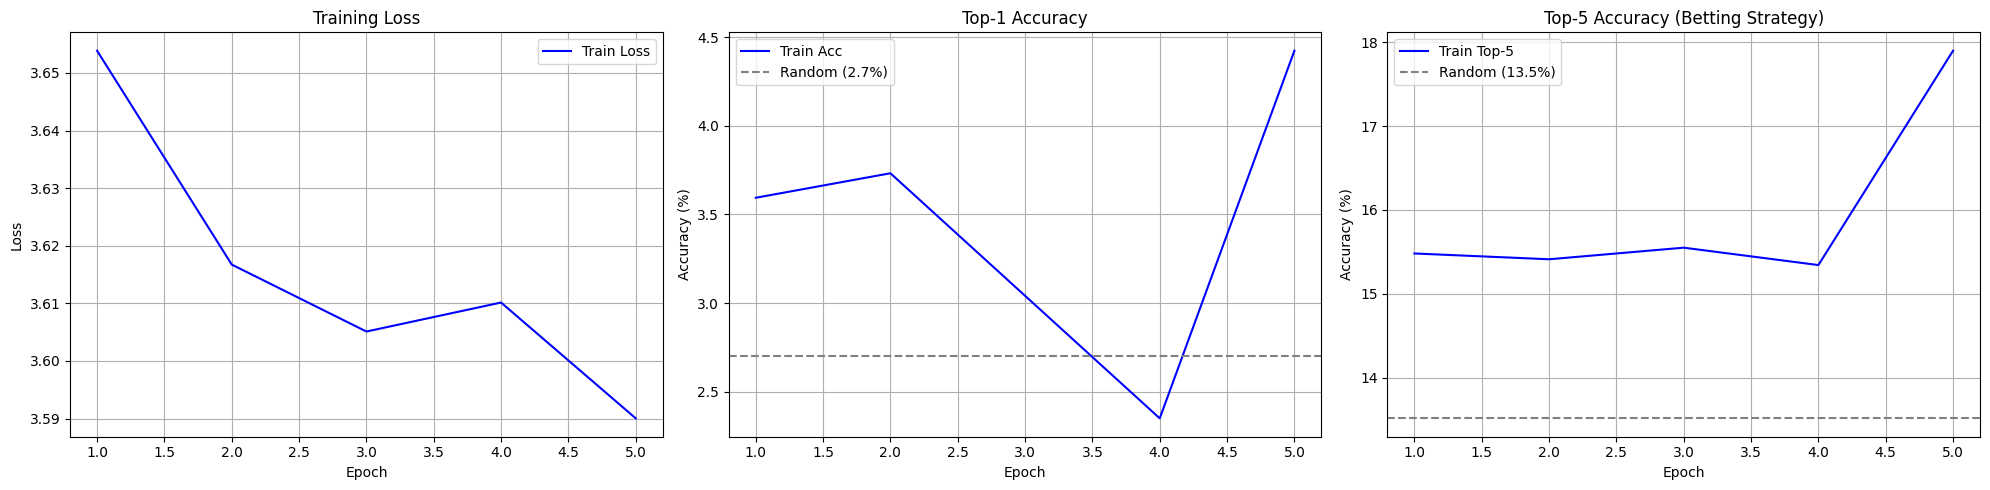

Testing: 100%|██████████| 32/32 [01:24<00:00,  2.65s/it, loss=3.65, acc=3.12, top5=14.8]
c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 


Test Set Evaluation Results
Test Loss: 3.6221

1. TOP-1 BETTING (1 unit on most likely number):
  Accuracy: 3.12%
  Random Baseline: 2.70%
  Improvement: 1.16x over random
  Expected return: 1.12 units
  Expected profit: 0.12 units per spin

2. TOP-5 EQUAL BETTING (1 unit each on top 5):
  Top-5 Accuracy: 14.84%
  Random Baseline: 13.51%
  Improvement: 1.10x over random
  Cost per spin: 5 units
  Expected return: 5.34 units
  Expected profit: 0.34 units per spin
  Break-even accuracy: 13.89%

3. TOP-5 PROPORTIONAL BETTING (5 units split by probability):
  Cost per spin: 5 units
  Expected return: 5.42 units
  Expected profit: 0.42 units per spin
  Improvement over equal betting: 22.4%

Classification Report:
              precision    recall  f1-score   support

           0       0.06      0.17      0.08         6
           1       0.00      0.00      0.00         8
           2       0.00      0.00      0.00         4
           3       0.07      0.25      0.11         4
          

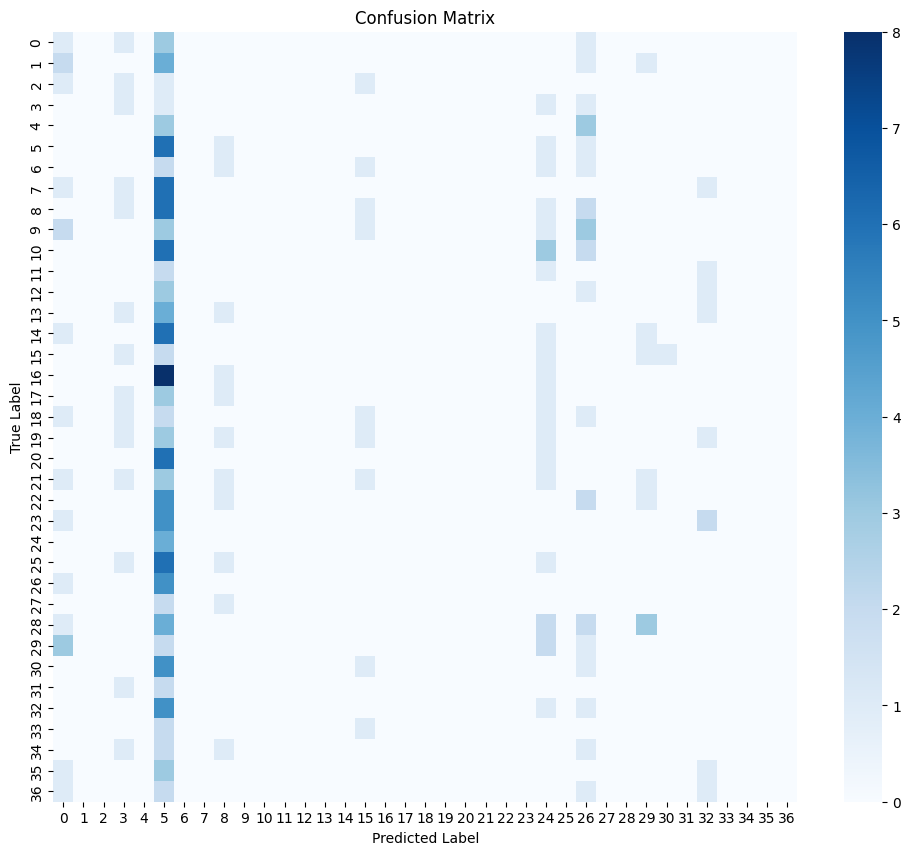

In [9]:
def plot_training_history(history):
    """Plot training metrics"""
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss plot
    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Top-1 Accuracy plot
    ax2.plot(epochs, history['train_acc'], 'b-', label='Train Acc')
    ax2.axhline(y=100/37, color='gray', linestyle='--', label='Random (2.7%)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Top-1 Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    # Top-5 Accuracy plot
    ax3.plot(epochs, history['train_top5_acc'], 'b-', label='Train Top-5')
    ax3.axhline(y=100*5/37, color='gray', linestyle='--', label='Random (13.5%)')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Accuracy (%)')
    ax3.set_title('Top-5 Accuracy (Betting Strategy)')
    ax3.legend()
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()

def evaluate_model(model, test_loader, device):
    """Detailed model evaluation on test set"""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    
    test_loss, test_acc, test_top5_acc, all_preds, all_labels, all_probs = test(
        model, test_loader, criterion, device
    )
    
    # Calculate proportional betting metrics
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    
    total_bet_equal = 0
    total_winnings_equal = 0
    total_bet_prop = 0
    total_winnings_prop = 0
    
    for i in range(len(all_labels)):
        probs = all_probs[i]
        true_label = all_labels[i]
        
        # Get top-5 indices and probabilities
        top5_indices = np.argsort(probs)[-5:][::-1]
        top5_probs = probs[top5_indices]
        
        # Equal betting (1 unit each on top-5)
        total_bet_equal += 5
        if true_label in top5_indices:
            total_winnings_equal += 36  # Win 36 units (35:1 + original bet)
        
        # Proportional betting (5 units distributed by probability)
        prob_sum = top5_probs.sum()
        bets = (top5_probs / prob_sum) * 5  # Normalize to 5 units total
        total_bet_prop += 5
        
        if true_label in top5_indices:
            bet_amount = bets[np.where(top5_indices == true_label)[0][0]]
            total_winnings_prop += bet_amount * 36
    
    avg_return_equal = total_winnings_equal / len(all_labels)
    avg_profit_equal = avg_return_equal - 5
    avg_return_prop = total_winnings_prop / len(all_labels)
    avg_profit_prop = avg_return_prop - 5
    
    print(f"\n{'='*60}")
    print("Test Set Evaluation Results")
    print(f"{'='*60}")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"\n1. TOP-1 BETTING (1 unit on most likely number):")
    print(f"  Accuracy: {test_acc:.2f}%")
    print(f"  Random Baseline: {100/37:.2f}%")
    print(f"  Improvement: {test_acc / (100/37):.2f}x over random")
    print(f"  Expected return: {test_acc/100 * 36:.2f} units")
    print(f"  Expected profit: {test_acc/100 * 36 - 1:.2f} units per spin")
    
    print(f"\n2. TOP-5 EQUAL BETTING (1 unit each on top 5):")
    print(f"  Top-5 Accuracy: {test_top5_acc:.2f}%")
    print(f"  Random Baseline: {100*5/37:.2f}%")
    print(f"  Improvement: {test_top5_acc / (100*5/37):.2f}x over random")
    print(f"  Cost per spin: 5 units")
    print(f"  Expected return: {avg_return_equal:.2f} units")
    print(f"  Expected profit: {avg_profit_equal:.2f} units per spin")
    print(f"  Break-even accuracy: {5/36*100:.2f}%")
    
    print(f"\n3. TOP-5 PROPORTIONAL BETTING (5 units split by probability):")
    print(f"  Cost per spin: 5 units")
    print(f"  Expected return: {avg_return_prop:.2f} units")
    print(f"  Expected profit: {avg_profit_prop:.2f} units per spin")
    if avg_profit_prop > avg_profit_equal:
        improvement = (avg_profit_prop / avg_profit_equal - 1) * 100 if avg_profit_equal > 0 else float('inf')
        print(f"  Improvement over equal betting: {improvement:.1f}%")
    else:
        print(f"  Equal betting performs better")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(37)]))
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return test_acc

plot_training_history(history)
final_acc = evaluate_model(model, test_loader, device)

## 8. Inference Function

Make predictions on new videos.

In [ ]:
def predict_video(model, video_path, dataset_root, num_frames=16, frame_size=112, device='cuda'):
    """
    Predict roulette outcome for a single video
    
    Returns:
        predicted_number: Most likely number (0-36)
        probabilities: Probability distribution over all 37 numbers
    """
    model.eval()
    
    # Create temporary dataset for single video
    temp_df = pd.DataFrame([{
        'input_path': video_path,
        'label': 0  # Dummy label
    }])
    temp_csv = 'temp_inference.csv'
    temp_df.to_csv(temp_csv, index=False)
    
    dataset = RouletteVideoDataset(
        csv_path=temp_csv,
        dataset_root=dataset_root,
        num_frames=num_frames,
        frame_size=frame_size
    )
    
    video_tensor, _ = dataset[0]
    video_tensor = video_tensor.unsqueeze(0).to(device)  # Add batch dimension
    
    with torch.no_grad():
        outputs = model(video_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]
        predicted_number = torch.argmax(probabilities).item()
    
    # Clean up
    Path(temp_csv).unlink()
    
    return predicted_number, probabilities.cpu().numpy()

# video_path = 'Input-Output Videos/SET 1/S1_INPUT_1.mp4'
# pred_num, probs = predict_video(model, video_path, CONFIG['dataset_root'], device=device)
# print(f"Predicted number: {pred_num}")
# print(f"Confidence: {probs[pred_num]*100:.2f}%")
# 
# # Show top 5 predictions
# top5_indices = np.argsort(probs)[-5:][::-1]
# print("\nTop 5 predictions:")
# for idx in top5_indices:
#     print(f"  Number {idx}: {probs[idx]*100:.2f}%")

Inference function ready!
